In [103]:
import os
import pandas as pd 
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
# Fakequakes rupture csv
rupture_csv_file = os.path.join('Z:\\', 'McGrath', 'HikurangiFakeQuakes', 'hikkerm', 'output', 'hikkerk_3e10_locking_NZNSHMscaling_df_n50000.csv')
rupture_df = pd.read_csv(rupture_csv_file, usecols=['rupt_id', 'mw'])

columns = ['merged'] + [isl for isl in range(10)]

In [123]:
# OCC file
rupt_dict_file = os.path.join('Z:\\', 'McGrath', 'occ-coseismic', 'results', 'fq_hikkerk', f'sites_sz_fq_3lhb110_full', f'all_rupture_disps_sites_sz_fq_3lhb110_full_uniform.pkl')
rate_dict_file = os.path.join('Z:\\', 'McGrath', 'occ-coseismic', 'data', 'sz_solutions', f'FQ_hk_lock_3e10_n5000_S10_N1_GR500_nr1-7_taper9-5Mw_alphas1-0_b1-1_nIt500000_narchi10_sense', 'solution', 'rates.csv')

rate_df = pd.read_csv(rate_dict_file)
rupt_dict = pkl.load(open(rupt_dict_file, 'rb'))

rupture_ix = []
rates = []
ix = 0
for rupt in rupt_dict.keys():
    rate = rupt_dict[rupt]['annual_rate']
    while rate_df.iloc[ix]['Annual Rate'] != rate:
        ix += 1
    rupture_ix.append(int(rate_df.iloc[ix]['Rupture Index']))
    rates.append(rate)
magnitudes=[]

for ix in rupture_ix:
    magnitudes.append(rupture_df.iloc[ix]['mw'])

n_rupts = len(magnitudes)

mw_df = pd.DataFrame(index=np.arange(n_rupts), columns=columns)
rates_df = pd.DataFrame(index=np.arange(n_rupts), columns=columns)

mw_df['merged'] = pd.Series(magnitudes).reset_index(drop=True)
rates_df['merged'] = pd.Series(rates).reset_index(drop=True)

In [124]:
mw_df

,merged,0,1,2,3,4,5,6,7,8,9
0,6.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8289,7.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8290,6.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8291,6.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8292,6.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [128]:
for archi in range(10):
    # OCC file
    rupt_dict_file = os.path.join('Z:\\', 'McGrath', 'occ-coseismic', 'results', 'fq_hikkerk', f'sites_sz_fq_3lhb110_full_n{archi}', f'all_rupture_disps_sites_sz_fq_3lhb110_full_n{archi}_uniform.pkl')
    rate_dict_file = os.path.join('Z:\\', 'McGrath', 'occ-coseismic', 'data', 'sz_solutions', f'FQ_hk_lock_3e10_n5000_S10_N1_GR500_nr1-7_taper9-5Mw_alphas1-0_b1-1_nIt500000_archi{archi}', 'solution', 'rates.csv')
    
    rate_df = pd.read_csv(rate_dict_file)
    rupt_dict = pkl.load(open(rupt_dict_file, 'rb'))

    rupture_ix = []
    rates = []
    ix = 0
    for rupt in rupt_dict.keys():
        rate = rupt_dict[rupt]['annual_rate']
        while rate_df.iloc[ix]['Annual Rate'] != rate:
            ix += 1
        rupture_ix.append(int(rate_df.iloc[ix]['Rupture Index']))
        rates.append(rate)
    magnitudes=[]

    for ix in rupture_ix:
        magnitudes.append(rupture_df.iloc[5000 * archi + ix]['mw'])

    mw_df[archi] = pd.Series(magnitudes).reset_index(drop=True)
    rates_df[archi] = pd.Series(rates).reset_index(drop=True)

In [129]:
mw_df

,merged,0,1,2,3,4,5,6,7,8,9
0,6.64,6.64,9.13,7.99,8.13,7.37,9.06,8.18,7.06,7.82,8.45
1,7.25,7.25,6.55,7.18,8.58,7.22,8.00,7.27,9.49,7.56,6.54
2,7.29,7.29,7.99,6.88,6.82,8.16,7.50,6.56,7.14,8.08,8.63
3,7.01,7.01,7.92,7.43,6.75,7.76,7.36,6.62,6.90,6.83,6.60
4,6.70,6.70,6.83,7.79,8.95,9.07,8.04,7.45,8.00,6.75,7.10
...,...,...,...,...,...,...,...,...,...,...,...
8289,7.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8290,6.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8291,6.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8292,6.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
rates_df

,merged,0,1,2,3,4,5,6,7,8,9
0,0.000114,0.001140,0.000078,0.000010,0.000051,0.000068,0.000022,0.000187,0.000058,0.000074,0.000245
1,0.000109,0.001092,0.002200,0.000107,0.000010,0.000343,0.000020,0.000495,0.000001,0.000263,0.005154
2,0.000003,0.000028,0.000152,0.000827,0.000541,0.000208,0.000185,0.002513,0.000788,0.000083,0.000008
3,0.000092,0.000920,0.000008,0.000125,0.000382,0.000106,0.000125,0.000397,0.000319,0.000687,0.001763
4,0.000193,0.001932,0.001452,0.000006,0.000008,0.000162,0.000014,0.000206,0.000016,0.000990,0.000431
...,...,...,...,...,...,...,...,...,...,...,...
8289,0.000003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8290,0.000062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8291,0.000022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8292,0.000338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 0, 'Magnitude')

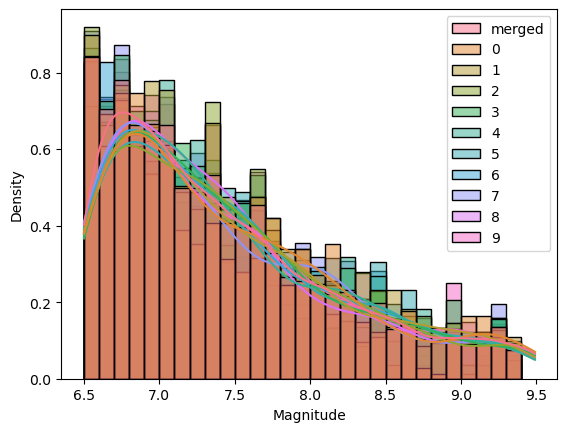

In [110]:
sns.histplot(data=mw_df, bins=np.arange(6.5, 9.5, 0.1), kde=True, common_norm=False, stat='density')
plt.xlabel('Magnitude')

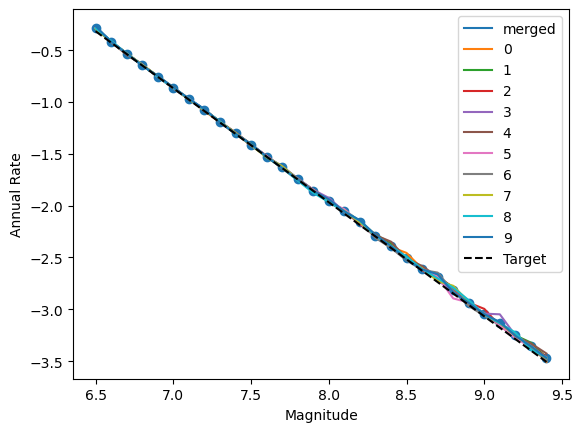

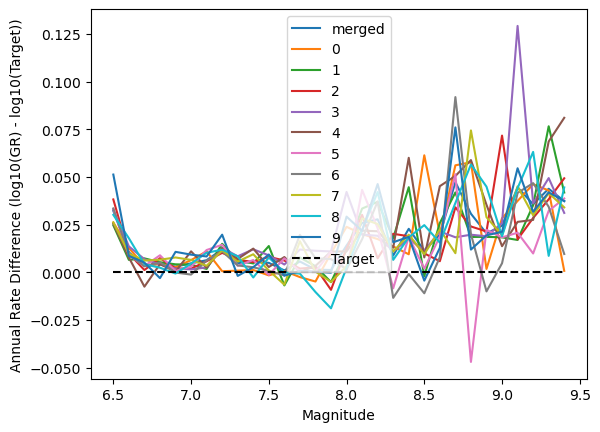

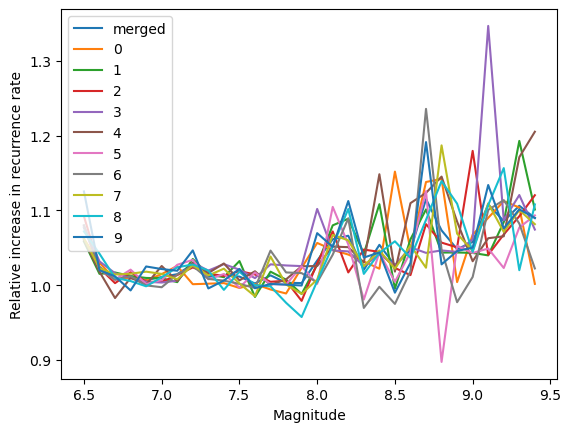

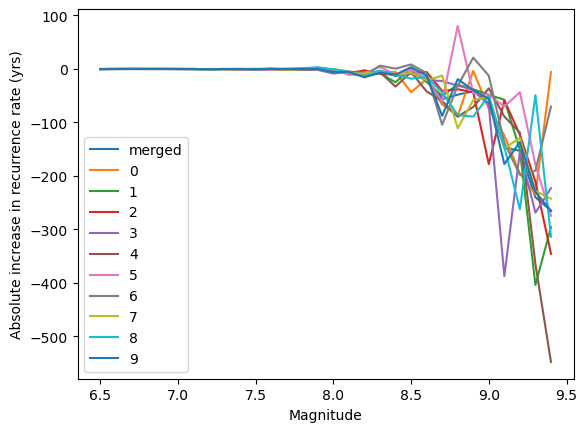

In [ ]:
mw_bins = np.arange(6.5, 9.5, 0.1)

b, n5 = 1.1, 21.5
a = np.log10(n5) + (b * 5)
target = 10**(a - (1.1 * mw_bins))

fig = plt.figure()
for archi in mw_df.columns:
    gr_grid = np.zeros((len(mw_bins), n_rupts))
    for ix, mw in enumerate(mw_bins):
        gr_grid[ix, :] = np.where((mw_df[archi] >= mw_bins[ix]), 1, 0)
    gr = np.nansum(gr_grid * rates_df[archi].T.values, axis=1)
    if archi == 'merged':
        plt.scatter(mw_bins, np.log10(gr))
    plt.plot(mw_bins, np.log10(gr), label=f'{archi}')

plt.plot(mw_bins, np.log10(target), 'k--', label='Target')
plt.xlabel('Magnitude')
plt.ylabel('Annual Rate')
plt.legend()
plt.show()


for archi in mw_df.columns:
    gr_grid = np.zeros((len(mw_bins), n_rupts))
    for ix, mw in enumerate(mw_bins):
        gr_grid[ix, :] = np.where((mw_df[archi] >= mw_bins[ix]), 1, 0)
    gr = np.nansum(gr_grid * rates_df[archi].T.values, axis=1)
    plt.plot(mw_bins, np.log10(gr) - np.log10(target), label=archi)

plt.plot(mw_bins, np.log10(target) - np.log10(target), 'k--', label='Target')
plt.xlabel('Magnitude')
plt.ylabel('Annual Rate Difference (log10(GR) - log10(Target))')
plt.legend()
plt.show()


for archi in mw_df.columns:
    gr_grid = np.zeros((len(mw_bins), n_rupts))
    for ix, mw in enumerate(mw_bins):
        gr_grid[ix, :] = np.where((mw_df[archi] >= mw_bins[ix]), 1, 0)
    gr = np.nansum(gr_grid * rates_df[archi].T.values, axis=1)
    plt.plot(mw_bins, 10 ** (np.log10(gr) - np.log10(target)), label=archi)

plt.xlabel('Magnitude')
plt.ylabel('Relative increase in recurrence interval')
plt.legend()
plt.show()


for archi in mw_df.columns:
    gr_grid = np.zeros((len(mw_bins), n_rupts))
    for ix, mw in enumerate(mw_bins):
        gr_grid[ix, :] = np.where((mw_df[archi] >= mw_bins[ix]), 1, 0)
    gr = np.nansum(gr_grid * rates_df[archi].T.values, axis=1)
    plt.plot(mw_bins, 1/gr - 1/target, label=archi)

plt.xlabel('Magnitude')
plt.ylabel('Absolute increase in recurrence interval (yrs)')
plt.legend()
plt.show()